In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
housing = fetch_california_housing()

In [4]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [5]:
df["MedHouseVal"]= housing.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.value_counts()

MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
8.3252  41.0      6.984127  1.023810   322.0       2.555556  37.88     -122.23    4.526          1
8.3014  21.0      6.238137  0.971880   2401.0      2.109842  37.86     -122.22    3.585          1
7.2574  52.0      8.288136  1.073446   496.0       2.802260  37.85     -122.24    3.521          1
5.6431  52.0      5.817352  1.073059   558.0       2.547945  37.85     -122.25    3.413          1
3.8462  52.0      6.281853  1.081081   565.0       2.181467  37.85     -122.25    3.422          1
                                                                                                ..
1.5603  25.0      5.045455  1.133333   845.0       2.560606  39.48     -121.09    0.781          1
2.5568  18.0      6.114035  1.315789   356.0       3.122807  39.49     -121.21    0.771          1
1.7000  17.0      5.205543  1.120092   1007.0      2.325635  39.43     -121.22    0.923          1
1.8672  18.0   

In [13]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [14]:
plt.Figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

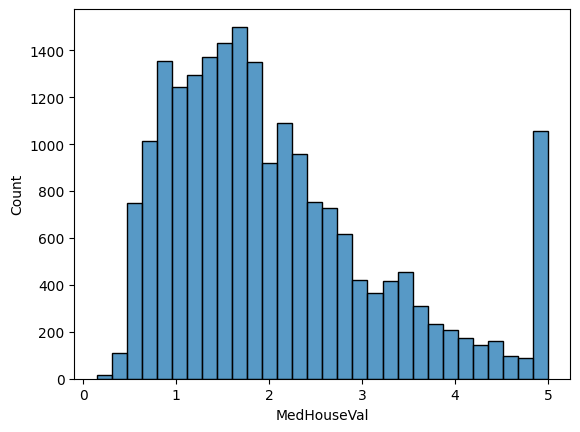

In [15]:
sns.histplot(df["MedHouseVal"], bins=30)
plt.show()

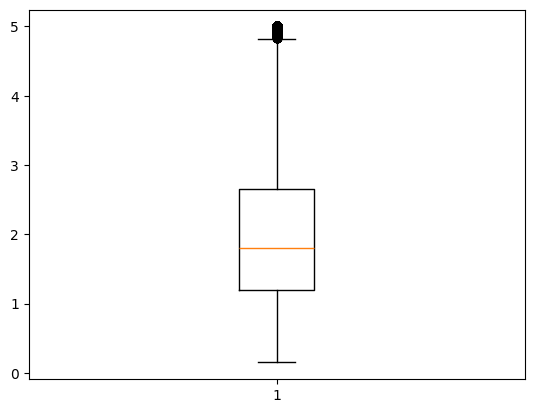

In [16]:
plt.boxplot(x=df["MedHouseVal"])
plt.show()

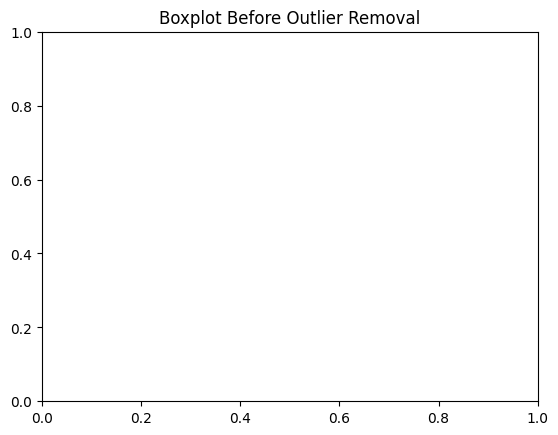

In [17]:
plt.title("Boxplot Before Outlier Removal")
plt.show()

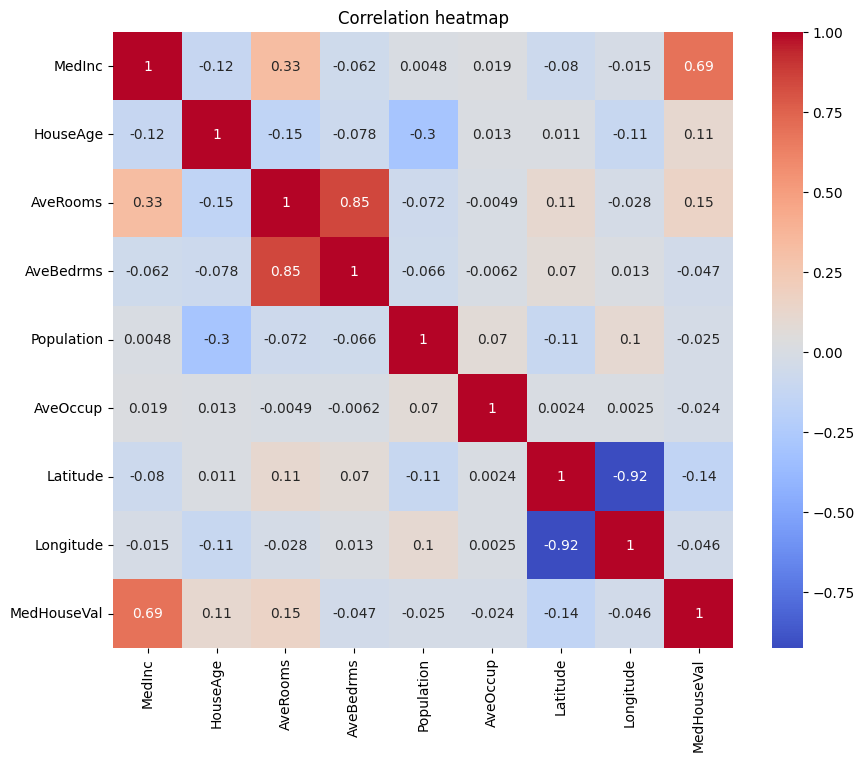

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [19]:
Q1 = df["MedInc"].quantile(0.25)
Q3 = df["MedInc"].quantile(0.75)

IQR = Q3 - Q1

In [20]:
lower = Q1 - 1.5 * IQR
upper = Q3 - 1.5 * IQR

df = df[
    (df["MedInc"] >= lower) &
    (df["MedInc"] <= upper)
    
     
    
    
]

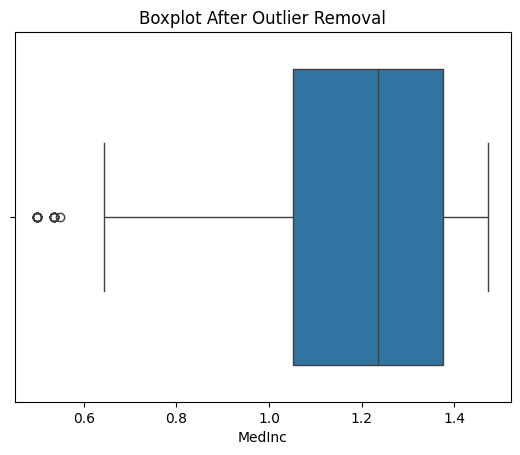

In [21]:
sns.boxplot(x=df["MedInc"])
plt.title("Boxplot After Outlier Removal")
plt.show()


In [22]:
median_price =df["MedHouseVal"].median()

In [ ]:
df["Housetype"] = ()